# Deeplearning Final Project


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import SeparableConv2D
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixels 0-1
    validation_split=0.2,     # 80% train, 20% val
    rotation_range=20,        # randomly rotate images up to 20 degrees
    width_shift_range=0.15,   # randomly shift left/right
    height_shift_range=0.15,  # randomly shift up/down
    zoom_range=0.15,          # randomly zoom in/out
    horizontal_flip=True,     # randomly flip horizontally
    brightness_range=[0.8, 1.2],  # simulate different lighting
    shear_range=0.1,          # slight perspective distortion
    fill_mode='nearest'       # fill empty pixels after shift/rotate
)

In [ ]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42                   # fixed seed = same split every run
)

validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,            # never shuffle val — keeps evaluation stable
    seed=42
)

print(f"Training samples  : {train_data.samples}")
print(f"Validation samples: {validation_data.samples}")
print(f"Class indices     : {train_data.class_indices}")
# Should show: 600 train, 150 val, 5 classes

Found 600 images belonging to 5 classes.
Found 150 images belonging to 5 classes.
Training samples  : 600
Validation samples: 150
Class indices     : {'hdmi': 0, 'rj45': 1, 'sata': 2, 'usba': 3, 'vga': 4}


In [ ]:
inputs = tf.keras.Input(shape=(128, 128, 3))

# Block 1 — detects basic edges and textures
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)   # NEW: stabilizes training
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.1)(x)          # NEW: drops 10% neurons to prevent memorization

# Block 2 — detects shapes and patterns
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.1)(x)

# Block 3 — detects high level connector features
# NEW: SeparableConv2D = fewer params than Conv2D, less overfitting
x = SeparableConv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Dropout(0.2)(x)

# NEW: GlobalAveragePooling replaces Flatten
# Flatten with 128x128 images = ~32000 neurons = massive overfit
# GlobalAveragePooling = just 128 values = much cleaner
x = layers.GlobalAveragePooling2D()(x)

# Classifier head
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)  # NEW: L2 penalty
x = layers.Dropout(0.4)(x)          # NEW: drops 40% before final prediction

outputs = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,341 (181.02 KB)

 Trainable params: 45,893 (179.27 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),   # explicit LR instead of default string
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    # Stops training if val_loss doesn't improve for 8 epochs
    # restore_best_weights = goes back to best checkpoint automatically
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        min_delta=0.001,
        verbose=1
    ),

    # Cuts learning rate by half if val_loss stalls for 3 epochs
    # Helps model fine-tune instead of overshooting
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    # Saves the best model to disk automatically
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_data,
    epochs=50,                    # EarlyStopping handles early exit
    validation_data=validation_data,
    callbacks=callbacks           # NEW: all three callbacks active
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3423 - loss: 1.6097 
Epoch 1: val_loss improved from None to 1.62246, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 300s 15s/step - accuracy: 0.4400 - loss: 1.3949 - val_accuracy: 0.2000 - val_loss: 1.6225 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5881 - loss: 1.0743
Epoch 2: val_loss did not improve from 1.62246
19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.5917 - loss: 1.0727 - val_accuracy: 0.2000 - val_loss: 1.6253 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7255 - loss: 0.8635
Epoch 3: val_loss did not improve from 1.62246
19/19 ━━━━━━━━━━━━━━━━━━━━ 135s 4s/step - accuracy: 0.7100 - loss: 0.8522 - val_accuracy: 0.2000 - val_loss: 1.6325 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7317 - loss: 0.7628
Epoch 4: ReduceLRO

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2000 - loss: 1.6224
Validation Accuracy: 0.2000
Validation Loss    : 1.6224


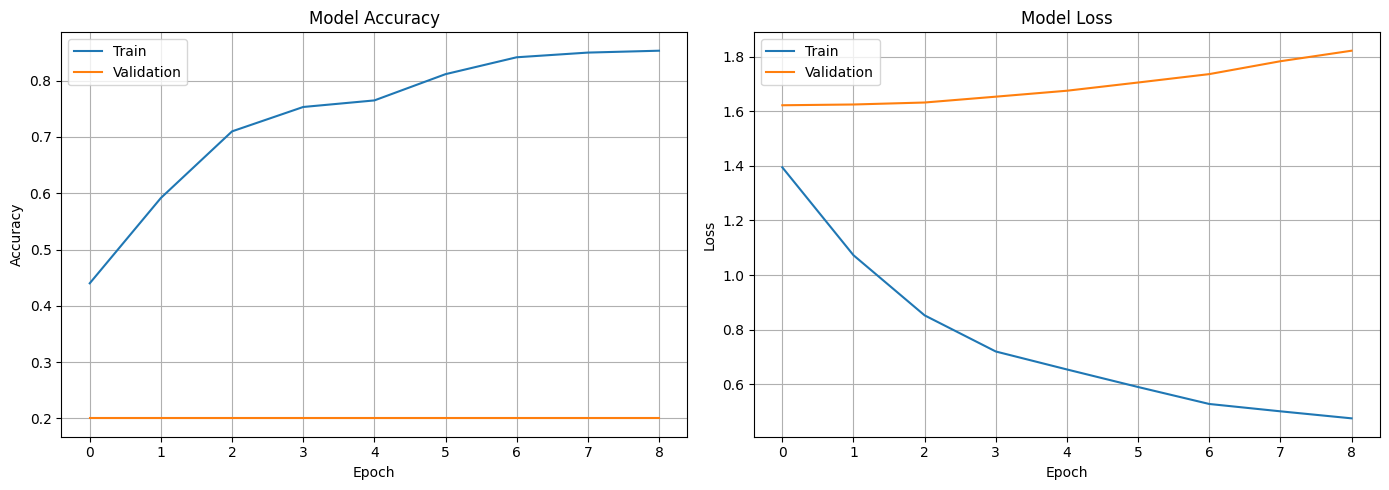

In [ ]:
loss, accuracy = model.evaluate(validation_data)
print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation Loss    : {loss:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_labels[predicted_class]} ({confidence:.1f}%)")
plt.show()